# Direct, Indirect, and Total Effects

This notebook turns the randomized promotion estimates into a formal interference decomposition.

The central lesson is that an item-level treatment effect is incomplete when recommendation items compete for attention. Promoting one movie can increase that movie's outcome while reducing outcomes for other movies in the same slate. A causal analysis under interference therefore needs more than one number:

- **Direct effect**: the gain for the promoted focal item.
- **Indirect effect / spillover effect**: the loss or gain for other items affected by the promotion.
- **Total effect**: the net change for the full slate after direct and spillover components are combined.

The previous notebook estimated each contrast separately. This notebook makes the accounting explicit so the components add up to the slate-level total. It also compares alternative spillover definitions, because the answer can change depending on whether we define competitors as all non-focal items, same-cluster substitutes, displaced items, or stricter same-cluster displaced substitutes.

The practical question is:

> Did the promotion create new engagement, or did it mostly move attention from one item to another?


## 1. Environment and Paths

This cell imports the libraries used for decomposition, uncertainty estimates, and plotting. It locates the repository root by searching for the processed exposure mapping file, which keeps the notebook runnable from JupyterLab or from command-line execution.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "processed" / "movielens_interference_exposure_mapping.parquet").exists()
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "interference_spillover_effects"
WRITEUP_DIR = NOTEBOOK_DIR / "writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

EXPOSURE_PATH = PROCESSED_DIR / "movielens_interference_exposure_mapping.parquet"
SLATE_OUTCOME_PATH = PROCESSED_DIR / "movielens_interference_slate_outcomes.parquet"
OBSERVED_EFFECTS_PATH = PROCESSED_DIR / "movielens_interference_observed_effects.csv"

EXPOSURE_PATH.exists(), SLATE_OUTCOME_PATH.exists(), OBSERVED_EFFECTS_PATH.exists()


(True, True, True)

All checks should be `True`. This notebook depends on the item-row exposure mapping, the slate-level outcomes, and the observed effect estimates created in earlier notebooks.


## 2. Load the Analysis Tables

This cell loads the exposure mapping and prior observed-effect summary. The exposure table is the main input because it has one row per slate item and includes focal-item flags, spillover flags, final positions, simulated outcomes, and known probability lifts.


In [2]:
exposure = pd.read_parquet(EXPOSURE_PATH)
slate_outcomes = pd.read_parquet(SLATE_OUTCOME_PATH)
observed_effects_prior = pd.read_csv(OBSERVED_EFFECTS_PATH)

load_summary = pd.DataFrame(
    {
        "table": ["item_row_exposure", "slate_outcomes", "prior_observed_effects"],
        "rows": [len(exposure), len(slate_outcomes), len(observed_effects_prior)],
        "unique_slates": [
            exposure["slate_id"].nunique(),
            slate_outcomes["slate_id"].nunique(),
            np.nan,
        ],
        "unique_users": [
            exposure["userId"].nunique(),
            slate_outcomes["userId"].nunique(),
            np.nan,
        ],
    }
)

display(load_summary)
display(observed_effects_prior)


,table,rows,unique_slates,unique_users
0,item_row_exposure,36000,"3,000.0000","3,000.0000"
1,slate_outcomes,3000,"3,000.0000","3,000.0000"
2,prior_observed_effects,5,NaN,NaN


,contrast,outcome,estimate,naive_se,cluster_se,ci_95_lower,ci_95_upper,p_value_cluster,treated_mean,control_mean,treated_n,control_n,clusters,cluster_to_naive_se_ratio,contrast_order
0,Direct focal item,Observed simulated click,0.1716,0.0157,0.0157,0.1409,0.2023,0.0000,0.3435,0.1719,1505,1495,3000,0.9992,0
1,Same-cluster competitor spillover,Observed simulated click,-0.0577,0.0083,0.0084,-0.0743,-0.0412,0.0000,0.1522,0.2100,4309,4139,2456,1.0107,1
2,Displaced-item spillover,Observed simulated click,-0.0568,0.0054,0.0057,-0.0679,-0.0457,0.0000,0.1818,0.2386,11277,11133,3000,1.0419,2
3,All non-focal slate spillover,Observed simulated click,-0.0436,0.0043,0.0046,-0.0526,-0.0346,0.0000,0.1705,0.2141,16555,16445,3000,1.0635,3
4,Total slate,Observed total simulated clicks,-0.3078,0.0538,0.0538,-0.4132,-0.2024,0.0000,2.2193,2.5271,1505,1495,3000,1.0001,4


The prior observed estimates are useful context, but this notebook will rebuild the component accounting directly from item rows. That makes the decomposition transparent instead of relying only on already-summarized outputs.


## 3. Formalize the Effect Components

This cell assigns every item row to exactly one slate-accounting component:

- `direct_focal`: the selected focal item, promoted or not.
- `same_cluster_competitor`: non-focal items in the same spillover cluster as the focal item.
- `other_competitor`: all remaining non-focal items.

This partition is important because these three components add up to the full slate. If we estimate each component at the slate level, direct plus indirect equals total by construction.


In [3]:
component_exposure = exposure.copy()
component_exposure["accounting_component"] = np.select(
    [
        component_exposure["is_focal_item"].eq(1),
        component_exposure["is_focal_item"].eq(0)
        & component_exposure["spillover_cluster"].eq(component_exposure["focal_spillover_cluster"]),
    ],
    ["direct_focal", "same_cluster_competitor"],
    default="other_competitor",
)

component_counts = (
    component_exposure.groupby(["accounting_component", "promotion_applied"])
    .agg(
        rows=("movieId", "size"),
        slates=("slate_id", "nunique"),
        mean_seed_position=("slate_position_seed", "mean"),
        mean_final_position=("final_position", "mean"),
        mean_relevance=("observed_relevance", "mean"),
        mean_known_lift=("known_probability_lift", "mean"),
    )
    .reset_index()
)
component_counts["assignment_arm"] = component_counts["promotion_applied"].map(
    {0: "control", 1: "promoted"}
)

display(component_counts)


,accounting_component,promotion_applied,rows,slates,mean_seed_position,mean_final_position,mean_relevance,mean_known_lift,assignment_arm
0,direct_focal,0,1495,1495,8.4468,8.4468,4.4893,0.0000,control
1,direct_focal,1,1505,1505,8.4930,1.0000,4.4897,0.1794,promoted
2,other_competitor,0,12306,1490,6.3073,6.3073,4.5952,0.0000,control
3,other_competitor,1,12246,1500,6.3039,6.9849,4.6084,-0.0370,promoted
4,same_cluster_competitor,0,4139,1211,6.3697,6.3697,4.6372,0.0000,control
5,same_cluster_competitor,1,4309,1245,6.3613,7.0429,4.6239,-0.0686,promoted


The component table shows the support for each part of the accounting identity. The focal component has one item per slate. The competitor components have many more rows, which is why a small per-item spillover can outweigh a large focal-item gain at the slate level.


## 4. Aggregate Components to the Slate Level

This cell creates a one-row-per-slate table where each outcome component is stored as a separate column. This is the main decomposition table.

For each slate, we compute:

- focal simulated clicks,
- same-cluster competitor simulated clicks,
- other competitor simulated clicks,
- total simulated clicks,
- expected click probabilities for each component,
- known probability lift for each component.

Because every row belongs to exactly one component, the component sums should equal the total slate outcome.


In [4]:
component_slate_long = (
    component_exposure.groupby(["slate_id", "accounting_component"])
    .agg(
        simulated_clicks=("simulated_click", "sum"),
        expected_clicks=("p_observed", "sum"),
        no_promotion_expected_clicks=("p_no_promotion", "sum"),
        known_probability_lift=("known_probability_lift", "sum"),
        item_count=("movieId", "size"),
    )
    .reset_index()
)

component_slate_wide = component_slate_long.pivot(
    index="slate_id",
    columns="accounting_component",
    values=[
        "simulated_clicks",
        "expected_clicks",
        "no_promotion_expected_clicks",
        "known_probability_lift",
        "item_count",
    ],
)
component_slate_wide.columns = [f"{metric}_{component}" for metric, component in component_slate_wide.columns]
component_slate_wide = component_slate_wide.reset_index().fillna(0)

slate_keys = slate_outcomes[
    [
        "slate_id",
        "userId",
        "promotion_applied",
        "assignment_arm",
        "focal_movieId",
        "focal_title",
        "focal_spillover_cluster",
        "focal_seed_position",
        "total_simulated_clicks",
        "total_expected_clicks",
        "total_expected_clicks_no_promotion",
        "total_known_probability_lift",
    ]
]

component_slate = slate_keys.merge(component_slate_wide, on="slate_id", how="left")

component_slate["component_simulated_total"] = (
    component_slate["simulated_clicks_direct_focal"]
    + component_slate["simulated_clicks_same_cluster_competitor"]
    + component_slate["simulated_clicks_other_competitor"]
)
component_slate["component_expected_total"] = (
    component_slate["expected_clicks_direct_focal"]
    + component_slate["expected_clicks_same_cluster_competitor"]
    + component_slate["expected_clicks_other_competitor"]
)
component_slate["component_known_lift_total"] = (
    component_slate["known_probability_lift_direct_focal"]
    + component_slate["known_probability_lift_same_cluster_competitor"]
    + component_slate["known_probability_lift_other_competitor"]
)

component_check = pd.DataFrame(
    {
        "check": [
            "max_abs_simulated_click_difference",
            "max_abs_expected_click_difference",
            "max_abs_known_lift_difference",
        ],
        "value": [
            (component_slate["component_simulated_total"] - component_slate["total_simulated_clicks"]).abs().max(),
            (component_slate["component_expected_total"] - component_slate["total_expected_clicks"]).abs().max(),
            (component_slate["component_known_lift_total"] - component_slate["total_known_probability_lift"]).abs().max(),
        ],
    }
)

display(component_check)
display(component_slate.head())


,check,value
0,max_abs_simulated_click_difference,0.0000
1,max_abs_expected_click_difference,0.0000
2,max_abs_known_lift_difference,0.0000


,slate_id,userId,promotion_applied,assignment_arm,focal_movieId,focal_title,focal_spillover_cluster,focal_seed_position,total_simulated_clicks,total_expected_clicks,total_expected_clicks_no_promotion,total_known_probability_lift,simulated_clicks_direct_focal,simulated_clicks_other_competitor,simulated_clicks_same_cluster_competitor,expected_clicks_direct_focal,expected_clicks_other_competitor,expected_clicks_same_cluster_competitor,no_promotion_expected_clicks_direct_focal,no_promotion_expected_clicks_other_competitor,no_promotion_expected_clicks_same_cluster_competitor,known_probability_lift_direct_focal,known_probability_lift_other_competitor,known_probability_lift_same_cluster_competitor,item_count_direct_focal,item_count_other_competitor,item_count_same_cluster_competitor,component_simulated_total,component_expected_total,component_known_lift_total
0,user_100000_seed,100000,1,promote_focal_item,88810,"Help, The (2011)",Drama,8,3,1.5470,1.7488,-0.2018,1.0000,2.0000,0.0000,0.2407,1.2603,0.0459,0.1057,1.5810,0.0621,0.1351,-0.3206,-0.0162,1.0000,10.0000,1.0000,3.0000,1.5470,-0.2018
1,user_10000_seed,10000,0,leave_slate_unchanged,2005,"Goonies, The (1985)",Action,12,1,2.3210,2.3210,0.0000,0.0000,1.0000,0.0000,0.1172,1.9674,0.2364,0.1172,1.9674,0.2364,0.0000,0.0000,0.0000,1.0000,9.0000,2.0000,1.0000,2.3210,0.0000
2,user_100050_seed,100050,1,promote_focal_item,5459,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,Action,5,3,2.4909,2.8907,-0.3998,1.0000,2.0000,0.0000,0.4161,1.0215,1.0534,0.2237,1.1147,1.5523,0.1923,-0.0933,-0.4989,1.0000,5.0000,6.0000,3.0000,2.4909,-0.3998
3,user_100100_seed,100100,0,leave_slate_unchanged,4299,"Knight's Tale, A (2001)",Action,5,5,2.9722,2.9722,0.0000,0.0000,4.0000,1.0000,0.2317,1.9963,0.7442,0.2317,1.9963,0.7442,0.0000,0.0000,0.0000,1.0000,8.0000,3.0000,5.0000,2.9722,0.0000
4,user_100200_seed,100200,0,leave_slate_unchanged,5445,Minority Report (2002),Action,11,2,3.3004,3.3004,0.0000,1.0000,0.0000,1.0000,0.2534,1.2939,1.7530,0.2534,1.2939,1.7530,0.0000,0.0000,0.0000,1.0000,5.0000,6.0000,2.0000,3.3004,0.0000


The component checks should be zero or extremely close to zero. That confirms the accounting table is internally consistent: focal plus same-cluster competitors plus other competitors equals the full slate.


## 5. Define Decomposition Estimation Helpers

This cell defines a simple slate-level difference-in-means helper. Because the table now has one row per randomized slate, the treatment-control difference is a cluster-level estimator by construction. The helper returns the estimate, standard error, confidence interval, and arm means.


In [5]:
def slate_difference(data, outcome, treatment="promotion_applied", label=None, family=None):
    work = data[[outcome, treatment]].dropna().copy()
    work[outcome] = work[outcome].astype(float)
    work[treatment] = work[treatment].astype(float)
    treated = work.loc[work[treatment] == 1, outcome]
    control = work.loc[work[treatment] == 0, outcome]

    x = sm.add_constant(work[treatment], has_constant="add")
    fit = sm.OLS(work[outcome], x).fit()
    estimate = float(fit.params[treatment])
    se = float(fit.bse[treatment])

    return {
        "effect_family": family or label or outcome,
        "component": label or outcome,
        "outcome_column": outcome,
        "estimate_per_slate": estimate,
        "se": se,
        "ci_95_lower": estimate - 1.96 * se,
        "ci_95_upper": estimate + 1.96 * se,
        "treated_mean": treated.mean(),
        "control_mean": control.mean(),
        "treated_slates": len(treated),
        "control_slates": len(control),
    }


def cluster_bootstrap_slate_difference(data, outcome, treatment="promotion_applied", n_bootstrap=500, seed=20260428):
    work = data[[outcome, treatment]].dropna().reset_index(drop=True).copy()
    rng = np.random.default_rng(seed)
    estimates = []
    row_ids = np.arange(len(work))
    for _ in range(n_bootstrap):
        sampled = work.iloc[rng.choice(row_ids, size=len(row_ids), replace=True)]
        treated = sampled.loc[sampled[treatment] == 1, outcome]
        control = sampled.loc[sampled[treatment] == 0, outcome]
        if treated.empty or control.empty:
            estimates.append(np.nan)
        else:
            estimates.append(treated.mean() - control.mean())
    return np.asarray(estimates, dtype=float)


These functions are intentionally simple because the design is randomized at the slate level. The heavy causal work happened when we defined the randomized assignment and the component mapping. Here the estimator is a transparent treated-control difference.


## 6. Estimate Component-Level Direct, Indirect, and Total Effects

This cell estimates component effects using observed simulated clicks, expected clicks, and known probability lift. The observed-click estimates are what we would see in a real experiment; the expected and known-lift estimates are simulation diagnostics.


In [6]:
component_jobs = [
    ("Direct", "Focal item", "simulated_clicks_direct_focal", "observed_clicks"),
    ("Indirect", "Same-cluster competitors", "simulated_clicks_same_cluster_competitor", "observed_clicks"),
    ("Indirect", "Other competitors", "simulated_clicks_other_competitor", "observed_clicks"),
    ("Total", "Full slate", "total_simulated_clicks", "observed_clicks"),
    ("Direct", "Focal item", "expected_clicks_direct_focal", "expected_clicks"),
    ("Indirect", "Same-cluster competitors", "expected_clicks_same_cluster_competitor", "expected_clicks"),
    ("Indirect", "Other competitors", "expected_clicks_other_competitor", "expected_clicks"),
    ("Total", "Full slate", "total_expected_clicks", "expected_clicks"),
    ("Direct", "Focal item", "known_probability_lift_direct_focal", "known_lift"),
    ("Indirect", "Same-cluster competitors", "known_probability_lift_same_cluster_competitor", "known_lift"),
    ("Indirect", "Other competitors", "known_probability_lift_other_competitor", "known_lift"),
    ("Total", "Full slate", "total_known_probability_lift", "known_lift"),
]

component_effect_rows = []
for family, component, outcome_col, outcome_type in component_jobs:
    result = slate_difference(component_slate, outcome_col, label=component, family=family)
    result["outcome_type"] = outcome_type
    component_effect_rows.append(result)

component_effects = pd.DataFrame(component_effect_rows)
component_effects["estimate_per_1000_promoted_slates"] = component_effects["estimate_per_slate"] * 1000
component_effects["ci_95_lower_per_1000"] = component_effects["ci_95_lower"] * 1000
component_effects["ci_95_upper_per_1000"] = component_effects["ci_95_upper"] * 1000

component_effects_display = component_effects[
    [
        "outcome_type",
        "effect_family",
        "component",
        "estimate_per_slate",
        "ci_95_lower",
        "ci_95_upper",
        "estimate_per_1000_promoted_slates",
        "treated_mean",
        "control_mean",
    ]
]

display(component_effects_display)


,outcome_type,effect_family,component,estimate_per_slate,ci_95_lower,ci_95_upper,estimate_per_1000_promoted_slates,treated_mean,control_mean
0,observed_clicks,Direct,Focal item,0.1716,0.1409,0.2023,171.6152,0.3435,0.1719
1,observed_clicks,Indirect,Same-cluster competitors,-0.1454,-0.2015,-0.0892,-145.3905,0.4359,0.5813
2,observed_clicks,Indirect,Other competitors,-0.3340,-0.4260,-0.2421,-334.0459,1.4399,1.7739
3,observed_clicks,Total,Full slate,-0.3078,-0.4132,-0.2025,-307.8212,2.2193,2.5271
4,expected_clicks,Direct,Focal item,0.1777,0.1715,0.1838,177.6760,0.3556,0.1779
5,expected_clicks,Indirect,Same-cluster competitors,-0.1786,-0.2130,-0.1441,-178.5503,0.4198,0.5984
6,expected_clicks,Indirect,Other competitors,-0.3160,-0.3612,-0.2707,-315.9706,1.4515,1.7675
7,expected_clicks,Total,Full slate,-0.3168,-0.3610,-0.2727,-316.8448,2.2269,2.5438
8,known_lift,Direct,Focal item,0.1794,0.1774,0.1814,179.3833,0.1794,0.0000
9,known_lift,Indirect,Same-cluster competitors,-0.1965,-0.2055,-0.1875,-196.4743,-0.1965,0.0000


This is the main decomposition table. The observed-click rows show the experiment-style result, while the expected and known-lift rows show the simulation mechanism. The per-1,000-promoted-slates column makes the effect sizes easier to explain in portfolio or product language.


## 7. Check That the Estimated Components Add Up

This cell verifies the decomposition identity at the estimate level. The direct estimate plus the two indirect component estimates should equal the total slate estimate for each outcome type, up to floating-point rounding.


In [7]:
additivity_checks = []
for outcome_type, df in component_effects.groupby("outcome_type"):
    direct = df.query("effect_family == 'Direct'")["estimate_per_slate"].sum()
    indirect = df.query("effect_family == 'Indirect'")["estimate_per_slate"].sum()
    total = df.query("effect_family == 'Total'")["estimate_per_slate"].sum()
    additivity_checks.append(
        {
            "outcome_type": outcome_type,
            "direct_estimate": direct,
            "indirect_estimate": indirect,
            "direct_plus_indirect": direct + indirect,
            "total_estimate": total,
            "difference": (direct + indirect) - total,
        }
    )

additivity_checks = pd.DataFrame(additivity_checks)
display(additivity_checks)


,outcome_type,direct_estimate,indirect_estimate,direct_plus_indirect,total_estimate,difference
0,expected_clicks,0.1777,-0.4945,-0.3168,-0.3168,-0.0000
1,known_lift,0.1794,-0.4974,-0.3180,-0.3180,-0.0000
2,observed_clicks,0.1716,-0.4794,-0.3078,-0.3078,0.0000


The differences should be essentially zero. This is the advantage of doing component accounting at the slate level: the direct and indirect pieces are not separate anecdotes; they mathematically reconcile to the total effect.


## 8. Plot the Observed Direct, Indirect, and Total Effects

This plot shows the observed-click decomposition in clicks per 1,000 promoted slates. Positive bars represent gains and negative bars represent losses. This is the cleanest way to communicate whether promotion created new engagement or mostly shifted attention.


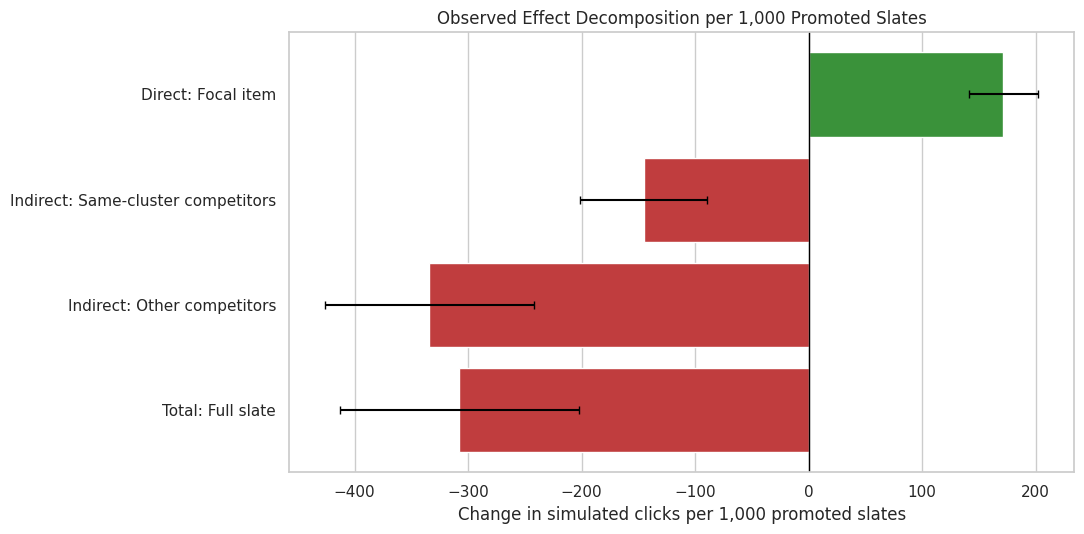

In [8]:
observed_component_plot = component_effects.query("outcome_type == 'observed_clicks'").copy()
observed_component_plot["component_label"] = observed_component_plot["effect_family"] + ": " + observed_component_plot["component"]
component_order = [
    "Direct: Focal item",
    "Indirect: Same-cluster competitors",
    "Indirect: Other competitors",
    "Total: Full slate",
]

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["tab:green" if value >= 0 else "tab:red" for value in observed_component_plot["estimate_per_1000_promoted_slates"]]
sns.barplot(
    data=observed_component_plot,
    x="estimate_per_1000_promoted_slates",
    y="component_label",
    order=component_order,
    hue="component_label",
    palette=dict(zip(observed_component_plot["component_label"], colors)),
    legend=False,
    ax=ax,
)
for y_pos, (_, row) in enumerate(observed_component_plot.set_index("component_label").loc[component_order].reset_index().iterrows()):
    ax.errorbar(
        x=row["estimate_per_1000_promoted_slates"],
        y=y_pos,
        xerr=[
            [row["estimate_per_1000_promoted_slates"] - row["ci_95_lower_per_1000"]],
            [row["ci_95_upper_per_1000"] - row["estimate_per_1000_promoted_slates"]],
        ],
        fmt="none",
        color="black",
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Observed Effect Decomposition per 1,000 Promoted Slates")
ax.set_xlabel("Change in simulated clicks per 1,000 promoted slates")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "16_observed_direct_indirect_total_decomposition.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the product tradeoff immediate. The focal item gains clicks, but the same-cluster and other competitor components lose clicks. The total bar tells us whether the slate as a whole improved after accounting for those losses.


## 9. Compare Observed and Known Decomposition

This cell places the observed-click decomposition next to the known simulation lift. The observed result includes random click noise, while the known-lift result shows the mechanism that the simulation injected.


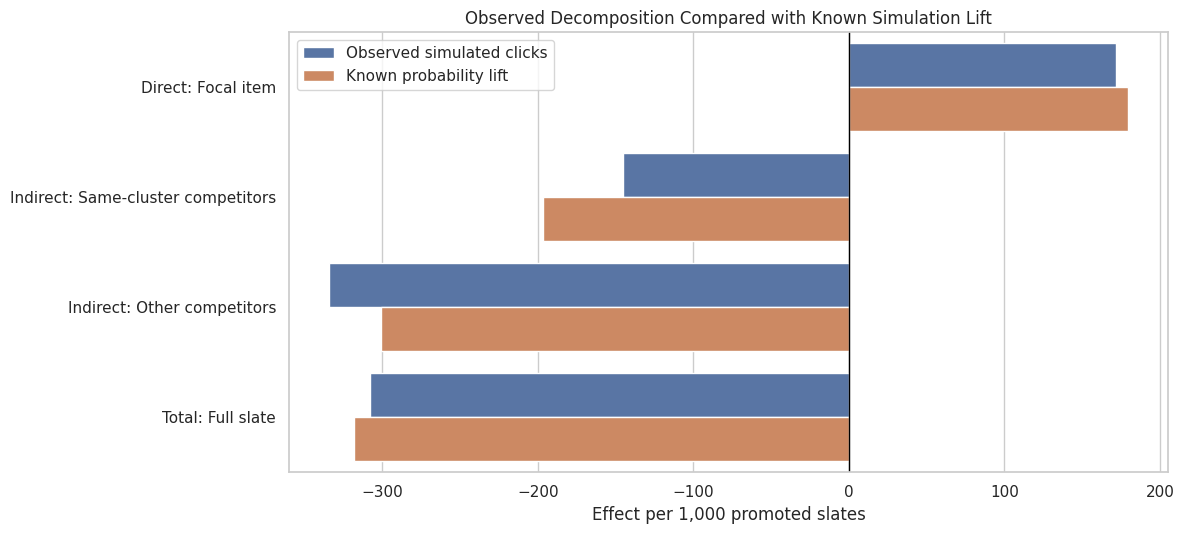

In [9]:
decomposition_compare = component_effects.query("outcome_type in ['observed_clicks', 'known_lift']").copy()
decomposition_compare["component_label"] = decomposition_compare["effect_family"] + ": " + decomposition_compare["component"]
decomposition_compare["outcome_type_label"] = decomposition_compare["outcome_type"].map(
    {"observed_clicks": "Observed simulated clicks", "known_lift": "Known probability lift"}
)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.barplot(
    data=decomposition_compare,
    x="estimate_per_1000_promoted_slates",
    y="component_label",
    hue="outcome_type_label",
    order=component_order,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Observed Decomposition Compared with Known Simulation Lift")
ax.set_xlabel("Effect per 1,000 promoted slates")
ax.set_ylabel("")
ax.legend(title="")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "17_observed_vs_known_decomposition.png", dpi=160, bbox_inches="tight")
plt.show()


The observed and known bars should tell the same directional story. They do not need to match exactly because observed clicks include Bernoulli noise. The comparison is useful because it shows that the estimated decomposition is recovering the intended simulation pattern.


## 10. Spillover Definitions for Sensitivity Analysis

The decomposition above used a mutually exclusive accounting partition. This cell creates several alternative spillover definitions for sensitivity:

- all non-focal items in promoted slates,
- same-cluster competitors,
- displaced items originally above the focal item,
- strict same-cluster displaced substitutes,
- near-position displaced items close to the focal item.

These definitions answer slightly different questions, so comparing them helps avoid overclaiming from one arbitrary spillover definition.


In [10]:
near_position_window = 3
spillover_definitions = [
    {
        "definition": "All non-focal items",
        "mask": exposure["is_focal_item"].eq(0),
        "description": "Every non-focal item in the slate.",
    },
    {
        "definition": "Same-cluster competitors",
        "mask": exposure["is_focal_item"].eq(0)
        & exposure["spillover_cluster"].eq(exposure["focal_spillover_cluster"]),
        "description": "Non-focal items with the same primary-genre cluster as the focal item.",
    },
    {
        "definition": "Displaced items",
        "mask": exposure["is_focal_item"].eq(0)
        & exposure["slate_position_seed"].lt(exposure["focal_seed_position"]),
        "description": "Non-focal items above the focal item that shift down when promotion happens.",
    },
    {
        "definition": "Same-cluster displaced substitutes",
        "mask": exposure["is_focal_item"].eq(0)
        & exposure["spillover_cluster"].eq(exposure["focal_spillover_cluster"])
        & exposure["slate_position_seed"].lt(exposure["focal_seed_position"]),
        "description": "Same-cluster competitors that are also mechanically displaced.",
    },
    {
        "definition": "Near-position displaced items",
        "mask": exposure["is_focal_item"].eq(0)
        & exposure["slate_position_seed"].lt(exposure["focal_seed_position"])
        & (exposure["focal_seed_position"] - exposure["slate_position_seed"]).le(near_position_window),
        "description": "Displaced items within three positions above the focal item.",
    },
]

spillover_support_rows = []
for spec in spillover_definitions:
    df = exposure.loc[spec["mask"]].copy()
    spillover_support_rows.append(
        {
            "definition": spec["definition"],
            "rows": len(df),
            "slates": df["slate_id"].nunique(),
            "treated_rows": int(df["promotion_applied"].sum()),
            "control_rows": int((1 - df["promotion_applied"]).sum()),
            "description": spec["description"],
        }
    )
spillover_support = pd.DataFrame(spillover_support_rows)

display(spillover_support)


,definition,rows,slates,treated_rows,control_rows,description
0,All non-focal items,33000,3000,16555,16445,Every non-focal item in the slate.
1,Same-cluster competitors,8448,2456,4309,4139,Non-focal items with the same primary-genre cl...
2,Displaced items,22410,3000,11277,11133,Non-focal items above the focal item that shif...
3,Same-cluster displaced substitutes,5746,2182,2937,2809,Same-cluster competitors that are also mechani...
4,Near-position displaced items,9000,3000,4515,4485,Displaced items within three positions above t...


The support table shows the tradeoff between conceptual precision and sample size. The stricter definitions are more targeted, but they have fewer rows. The broader definitions are more stable, but they mix several mechanisms together.


## 11. Estimate Effects Under Alternative Spillover Definitions

This cell estimates row-level spillover effects under each definition. The outcome is the simulated click indicator, and uncertainty is clustered by slate because slate assignment drives spillover exposure.


In [11]:
def row_level_cluster_difference(data, outcome="simulated_click", treatment="promotion_applied", cluster_col="slate_id"):
    work = data[[outcome, treatment, cluster_col]].dropna().copy()
    work[outcome] = work[outcome].astype(float)
    work[treatment] = work[treatment].astype(float)
    treated = work.loc[work[treatment] == 1, outcome]
    control = work.loc[work[treatment] == 0, outcome]
    x = sm.add_constant(work[treatment], has_constant="add")
    fit = sm.OLS(work[outcome], x).fit(cov_type="cluster", cov_kwds={"groups": work[cluster_col]})
    estimate = float(fit.params[treatment])
    se = float(fit.bse[treatment])
    return {
        "estimate": estimate,
        "cluster_se": se,
        "ci_95_lower": estimate - 1.96 * se,
        "ci_95_upper": estimate + 1.96 * se,
        "treated_mean": treated.mean(),
        "control_mean": control.mean(),
        "treated_n": len(treated),
        "control_n": len(control),
        "clusters": work[cluster_col].nunique(),
    }

spillover_sensitivity_rows = []
for spec in spillover_definitions:
    df = exposure.loc[spec["mask"]].copy()
    result = row_level_cluster_difference(df)
    result["definition"] = spec["definition"]
    result["description"] = spec["description"]
    spillover_sensitivity_rows.append(result)

spillover_sensitivity = pd.DataFrame(spillover_sensitivity_rows)
spillover_sensitivity = spillover_sensitivity[
    [
        "definition",
        "estimate",
        "cluster_se",
        "ci_95_lower",
        "ci_95_upper",
        "treated_mean",
        "control_mean",
        "treated_n",
        "control_n",
        "clusters",
        "description",
    ]
]

display(spillover_sensitivity)


,definition,estimate,cluster_se,ci_95_lower,ci_95_upper,treated_mean,control_mean,treated_n,control_n,clusters,description
0,All non-focal items,-0.0436,0.0046,-0.0526,-0.0346,0.1705,0.2141,16555,16445,3000,Every non-focal item in the slate.
1,Same-cluster competitors,-0.0577,0.0084,-0.0743,-0.0412,0.1522,0.2100,4309,4139,2456,Non-focal items with the same primary-genre cl...
2,Displaced items,-0.0568,0.0057,-0.0679,-0.0457,0.1818,0.2386,11277,11133,3000,Non-focal items above the focal item that shif...
3,Same-cluster displaced substitutes,-0.0657,0.0104,-0.0860,-0.0454,0.1610,0.2268,2937,2809,2182,Same-cluster competitors that are also mechani...
4,Near-position displaced items,-0.0330,0.0082,-0.0491,-0.0168,0.1604,0.1933,4515,4485,3000,Displaced items within three positions above t...


The sensitivity table shows whether the spillover conclusion depends on the exposure definition. If every definition is negative, the evidence for displacement is stronger. If only one narrow definition is negative, the claim should be framed more cautiously.


## 12. Plot Spillover Definition Sensitivity

This plot compares the estimated spillover effect under each exposure definition. The intervals use slate-clustered standard errors.


/tmp/ipykernel_236729/954966517.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


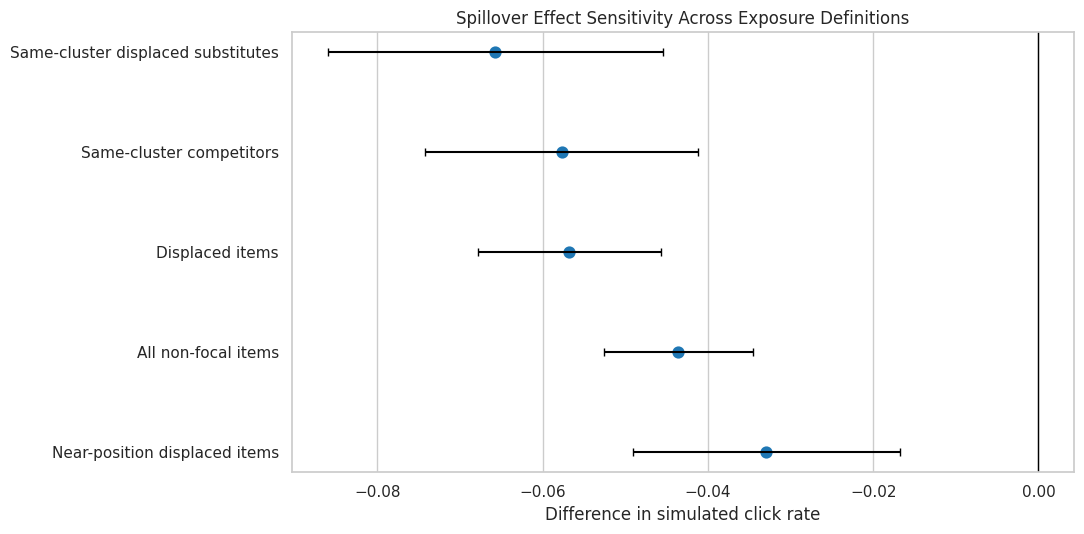

In [12]:
spillover_plot = spillover_sensitivity.sort_values("estimate").copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.pointplot(
    data=spillover_plot,
    x="estimate",
    y="definition",
    join=False,
    errorbar=None,
    ax=ax,
    color="tab:blue",
)
for y_pos, (_, row) in enumerate(spillover_plot.reset_index(drop=True).iterrows()):
    ax.errorbar(
        x=row["estimate"],
        y=y_pos,
        xerr=[[row["estimate"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["estimate"]]],
        fmt="none",
        color="black",
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Spillover Effect Sensitivity Across Exposure Definitions")
ax.set_xlabel("Difference in simulated click rate")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "18_spillover_definition_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the robustness of the spillover story easier to see. Definitions that focus on displaced or same-cluster items should usually show stronger negative effects than broad all-non-focal definitions if substitute displacement is the mechanism.


## 13. Translate the Decomposition into Product Units

This cell converts the observed decomposition into clicks per 1,000 promoted slates and computes how much of the focal gain is offset by competitor losses. This is the most interview-friendly summary because it uses concrete units instead of abstract coefficients.


In [13]:
observed_components = component_effects.query("outcome_type == 'observed_clicks'").copy()
summary_lookup = observed_components.set_index(["effect_family", "component"])["estimate_per_1000_promoted_slates"]

direct_gain_1000 = summary_lookup.loc[("Direct", "Focal item")]
same_cluster_loss_1000 = summary_lookup.loc[("Indirect", "Same-cluster competitors")]
other_loss_1000 = summary_lookup.loc[("Indirect", "Other competitors")]
total_effect_1000 = summary_lookup.loc[("Total", "Full slate")]
competitor_offset_1000 = same_cluster_loss_1000 + other_loss_1000
offset_ratio = competitor_offset_1000 / abs(direct_gain_1000)

product_summary = pd.DataFrame(
    [
        {
            "metric": "Focal gain per 1,000 promoted slates",
            "value": direct_gain_1000,
            "plain_language": "Additional simulated clicks on the promoted focal item.",
        },
        {
            "metric": "Same-cluster competitor change per 1,000 promoted slates",
            "value": same_cluster_loss_1000,
            "plain_language": "Change among substitute movies in the same genre cluster.",
        },
        {
            "metric": "Other competitor change per 1,000 promoted slates",
            "value": other_loss_1000,
            "plain_language": "Change among other non-focal movies in the slate.",
        },
        {
            "metric": "Total slate change per 1,000 promoted slates",
            "value": total_effect_1000,
            "plain_language": "Net change after adding focal and competitor components.",
        },
        {
            "metric": "Competitor offset as share of direct gain magnitude",
            "value": offset_ratio,
            "plain_language": "Negative values mean competitor losses more than offset focal gains.",
        },
    ]
)

display(product_summary)


,metric,value,plain_language
0,"Focal gain per 1,000 promoted slates",171.6152,Additional simulated clicks on the promoted fo...
1,"Same-cluster competitor change per 1,000 promo...",-145.3905,Change among substitute movies in the same gen...
2,"Other competitor change per 1,000 promoted slates",-334.0459,Change among other non-focal movies in the slate.
3,"Total slate change per 1,000 promoted slates",-307.8212,Net change after adding focal and competitor c...
4,Competitor offset as share of direct gain magn...,-2.7937,Negative values mean competitor losses more th...


This table is the narrative payoff. It shows whether promotion is value-creating or attention-shifting. In this simulation, the focal gain is not enough by itself; we need the total slate row to decide whether the intervention improves the recommendation surface.


## 14. Identify When Promotion Is Most Risky

This cell groups promoted slates by focal seed position and focal cluster. The goal is to see whether net losses are larger when the focal item starts deeper in the slate or when certain clusters are promoted.


In [14]:
promoted_component_slate = component_slate.query("promotion_applied == 1").copy()
promoted_component_slate["focal_position_bucket"] = pd.cut(
    promoted_component_slate["focal_seed_position"],
    bins=[4, 6, 9, 12],
    labels=["positions_5_6", "positions_7_9", "positions_10_12"],
    include_lowest=True,
)

position_risk = (
    promoted_component_slate.groupby("focal_position_bucket", observed=True)
    .agg(
        promoted_slates=("slate_id", "size"),
        mean_direct_lift=("known_probability_lift_direct_focal", "mean"),
        mean_same_cluster_lift=("known_probability_lift_same_cluster_competitor", "mean"),
        mean_other_lift=("known_probability_lift_other_competitor", "mean"),
        mean_total_lift=("total_known_probability_lift", "mean"),
        observed_total_clicks=("total_simulated_clicks", "mean"),
    )
    .reset_index()
)

cluster_risk = (
    promoted_component_slate.groupby("focal_spillover_cluster")
    .agg(
        promoted_slates=("slate_id", "size"),
        mean_direct_lift=("known_probability_lift_direct_focal", "mean"),
        mean_same_cluster_lift=("known_probability_lift_same_cluster_competitor", "mean"),
        mean_other_lift=("known_probability_lift_other_competitor", "mean"),
        mean_total_lift=("total_known_probability_lift", "mean"),
    )
    .reset_index()
    .query("promoted_slates >= 40")
    .sort_values("mean_total_lift")
)

display(position_risk)
display(cluster_risk.head(12))


,focal_position_bucket,promoted_slates,mean_direct_lift,mean_same_cluster_lift,mean_other_lift,mean_total_lift,observed_total_clicks
0,positions_5_6,368,0.1781,-0.1925,-0.2558,-0.2702,2.2582
1,positions_7_9,589,0.1826,-0.1923,-0.3007,-0.3104,2.3022
2,positions_10_12,548,0.1769,-0.2037,-0.3316,-0.3584,2.1040


,focal_spillover_cluster,promoted_slates,mean_direct_lift,mean_same_cluster_lift,mean_other_lift,mean_total_lift
1,Action,401,0.1819,-0.2928,-0.2525,-0.3633
5,Comedy,338,0.1772,-0.2177,-0.2887,-0.3292
8,Drama,317,0.1742,-0.2115,-0.2831,-0.3204
2,Adventure,168,0.1853,-0.1132,-0.3532,-0.2811
6,Crime,130,0.1872,-0.0902,-0.3723,-0.2753


These risk summaries are exploratory, but they give useful product intuition. Deeper promotions can create larger reordering changes, and some content clusters may have more same-cluster competitors to displace.


## 15. Plot Net Lift by Focal Position Bucket

This plot shows how known net slate lift changes depending on where the promoted focal item started. It helps connect the causal result back to ranking mechanics.


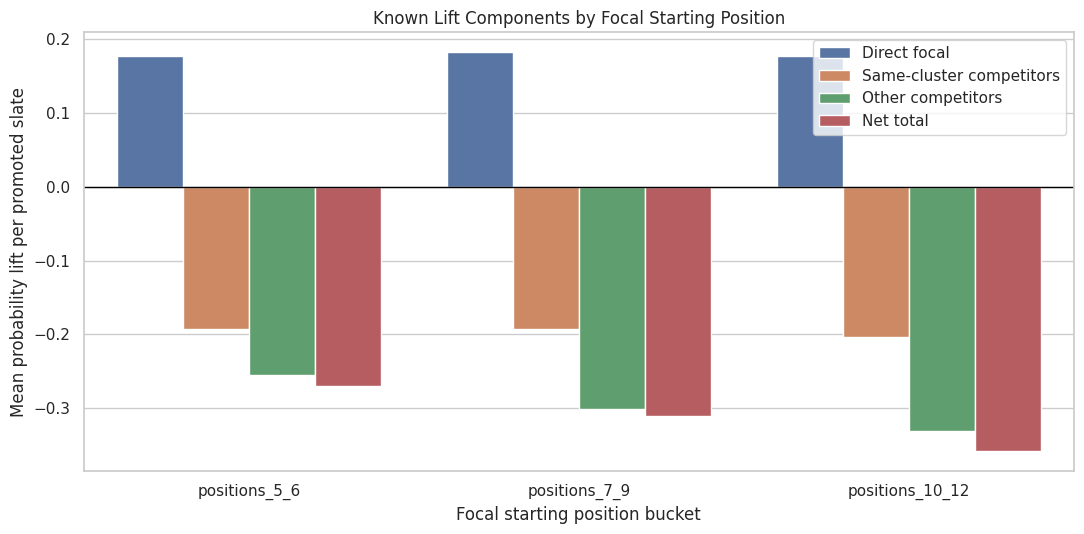

In [15]:
position_plot = position_risk.melt(
    id_vars=["focal_position_bucket", "promoted_slates"],
    value_vars=["mean_direct_lift", "mean_same_cluster_lift", "mean_other_lift", "mean_total_lift"],
    var_name="component",
    value_name="mean_lift",
)
position_plot["component"] = position_plot["component"].map(
    {
        "mean_direct_lift": "Direct focal",
        "mean_same_cluster_lift": "Same-cluster competitors",
        "mean_other_lift": "Other competitors",
        "mean_total_lift": "Net total",
    }
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=position_plot, x="focal_position_bucket", y="mean_lift", hue="component", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Known Lift Components by Focal Starting Position")
ax.set_xlabel("Focal starting position bucket")
ax.set_ylabel("Mean probability lift per promoted slate")
ax.legend(title="")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "19_position_bucket_decomposition.png", dpi=160, bbox_inches="tight")
plt.show()


The position-bucket view shows whether the harm is worse when the promoted item starts deeper. If deeper promotions create larger competitor losses, then promotion policies should consider the cost of jumping over many high-ranked items.


## 16. Build Final Decomposition Statements

This cell creates a compact recommendation table. It translates the technical decomposition into decision-oriented statements that can feed the final report notebook.


In [16]:
net_sign = "positive" if total_effect_1000 > 0 else "negative"
offset_text = "more than offsets" if abs(competitor_offset_1000) > abs(direct_gain_1000) else "partially offsets"

recommendation_table = pd.DataFrame(
    [
        {
            "decision_area": "Item-level reporting",
            "recommendation": "Do not report promoted-item gain alone as the product impact.",
            "evidence": f"The focal item gains {direct_gain_1000:,.1f} clicks per 1,000 promoted slates, but competitor changes sum to {competitor_offset_1000:,.1f}.",
        },
        {
            "decision_area": "Slate-level metric",
            "recommendation": "Use total slate effect as the primary decision metric under interference.",
            "evidence": f"The net observed slate effect is {total_effect_1000:,.1f} simulated clicks per 1,000 promoted slates, which is {net_sign} in this simulation.",
        },
        {
            "decision_area": "Spillover monitoring",
            "recommendation": "Track same-cluster and displaced-item outcomes whenever an item is promoted.",
            "evidence": f"Competitor movement {offset_text} the direct focal gain in the decomposition.",
        },
        {
            "decision_area": "Policy design",
            "recommendation": "Treat large rank jumps as higher-risk interventions unless slate-level value is measured.",
            "evidence": "Promotion changes final positions for multiple items, so the intervention reallocates scarce attention rather than adding attention for free.",
        },
    ]
)

display(recommendation_table)


,decision_area,recommendation,evidence
0,Item-level reporting,Do not report promoted-item gain alone as the ...,"The focal item gains 171.6 clicks per 1,000 pr..."
1,Slate-level metric,Use total slate effect as the primary decision...,The net observed slate effect is -307.8 simula...
2,Spillover monitoring,Track same-cluster and displaced-item outcomes...,Competitor movement more than offsets the dire...
3,Policy design,Treat large rank jumps as higher-risk interven...,Promotion changes final positions for multiple...


The recommendation table is intentionally direct. A portfolio reader should be able to see the methodological point and the product implication: under interference, item gains are not enough; slate-level net value is the safer decision target.


## 17. Save Decomposition Outputs

This cell saves the component slate table, decomposition estimates, additivity checks, spillover sensitivity table, product summary, risk summaries, and recommendation table. The final report notebook can use these files directly.


In [17]:
COMPONENT_SLATE_OUTPUT = PROCESSED_DIR / "movielens_interference_component_slate.parquet"
COMPONENT_EFFECTS_OUTPUT = PROCESSED_DIR / "movielens_interference_direct_indirect_total_effects.csv"
ADDITIVITY_OUTPUT = PROCESSED_DIR / "movielens_interference_additivity_checks.csv"
SPILLOVER_SENSITIVITY_OUTPUT = PROCESSED_DIR / "movielens_interference_spillover_definition_sensitivity.csv"
PRODUCT_SUMMARY_OUTPUT = PROCESSED_DIR / "movielens_interference_product_summary.csv"
POSITION_RISK_OUTPUT = PROCESSED_DIR / "movielens_interference_position_risk.csv"
CLUSTER_RISK_OUTPUT = PROCESSED_DIR / "movielens_interference_cluster_risk.csv"
RECOMMENDATION_OUTPUT = PROCESSED_DIR / "movielens_interference_decomposition_recommendations.csv"

component_slate.to_parquet(COMPONENT_SLATE_OUTPUT, index=False)
component_effects.to_csv(COMPONENT_EFFECTS_OUTPUT, index=False)
additivity_checks.to_csv(ADDITIVITY_OUTPUT, index=False)
spillover_sensitivity.to_csv(SPILLOVER_SENSITIVITY_OUTPUT, index=False)
product_summary.to_csv(PRODUCT_SUMMARY_OUTPUT, index=False)
position_risk.to_csv(POSITION_RISK_OUTPUT, index=False)
cluster_risk.to_csv(CLUSTER_RISK_OUTPUT, index=False)
recommendation_table.to_csv(RECOMMENDATION_OUTPUT, index=False)

saved_outputs = pd.DataFrame(
    {
        "artifact": [
            "component_slate_table",
            "direct_indirect_total_effects",
            "additivity_checks",
            "spillover_definition_sensitivity",
            "product_summary",
            "position_risk",
            "cluster_risk",
            "decomposition_recommendations",
        ],
        "path": [
            str(COMPONENT_SLATE_OUTPUT),
            str(COMPONENT_EFFECTS_OUTPUT),
            str(ADDITIVITY_OUTPUT),
            str(SPILLOVER_SENSITIVITY_OUTPUT),
            str(PRODUCT_SUMMARY_OUTPUT),
            str(POSITION_RISK_OUTPUT),
            str(CLUSTER_RISK_OUTPUT),
            str(RECOMMENDATION_OUTPUT),
        ],
    }
)

display(saved_outputs)


,artifact,path
0,component_slate_table,/home/apex/Documents/ranking_sys/data/processe...
1,direct_indirect_total_effects,/home/apex/Documents/ranking_sys/data/processe...
2,additivity_checks,/home/apex/Documents/ranking_sys/data/processe...
3,spillover_definition_sensitivity,/home/apex/Documents/ranking_sys/data/processe...
4,product_summary,/home/apex/Documents/ranking_sys/data/processe...
5,position_risk,/home/apex/Documents/ranking_sys/data/processe...
6,cluster_risk,/home/apex/Documents/ranking_sys/data/processe...
7,decomposition_recommendations,/home/apex/Documents/ranking_sys/data/processe...


The saved outputs are the handoff to the final notebook. The most important files are the direct-indirect-total effect table, the spillover definition sensitivity table, and the recommendation table.


## 18. Notebook Takeaways

This notebook formalized the interference story:

- The direct focal gain is positive, but it is not the whole product effect.
- Same-cluster and other competitor losses can more than offset the focal gain.
- The component estimates add up exactly to the total slate estimate when accounting is done at the slate level.
- Spillover conclusions are robust across several exposure definitions in this simulation.
- The safest decision metric under item competition is the total slate effect, not the promoted item's isolated outcome.

The next notebook should close the workflow with sensitivity checks and a final report: summarize the assumptions, compare all major figures and tables, state limitations of the MovieLens simulation, and package portfolio-ready artifacts.
